In [1]:
# ============================================
# MODULE 1: IMPORTING HANDWRITTEN MNIST DATA 
# ============================================

import numpy as np
import matplotlib.pyplot as plt 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten


(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [2]:
X_train.shape # 3-D array of 60k images of resolution 28x28

(60000, 28, 28)

In [3]:
X_train[0] # Image #1 with 


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

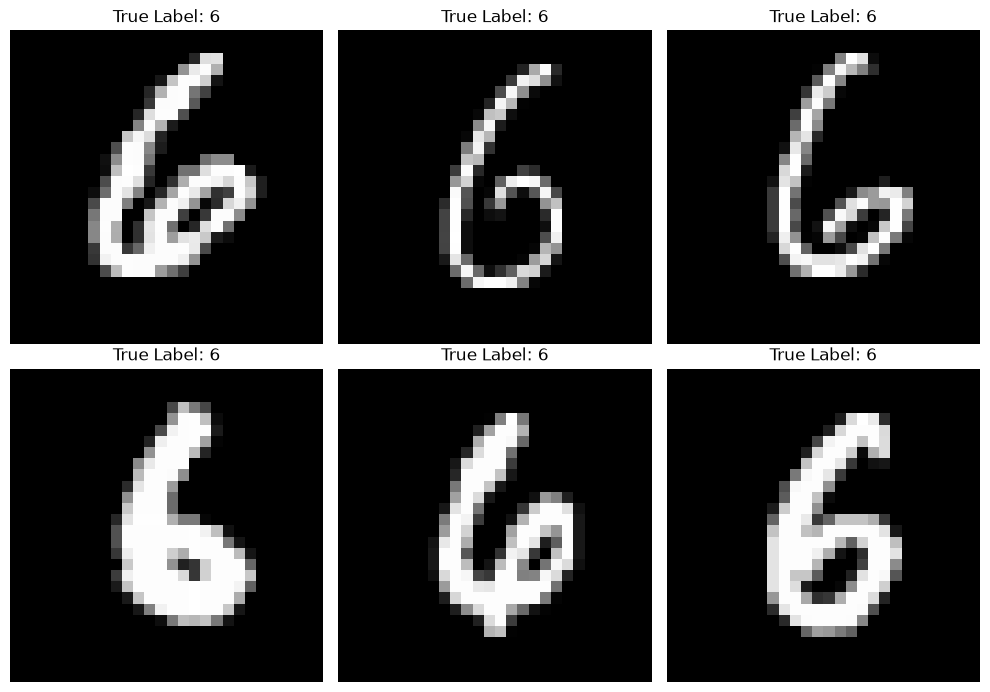

In [5]:
target_number = 6

if np.any(y_train == target_number):
    
    idx_found = np.where(y_train == target_number)[0] # Gives 1-D Array of indices 
    
    fig, axes = plt.subplots(2,3 ,figsize=(10, 7))
    axes = axes.flatten() # flatten to easily iterate
    
    for i in range(6):
        idx = idx_found[i]
        ax = axes[i]
        ax.imshow(X_train[idx], cmap='gray')
        ax.set_title(f'True Label: {y_train[idx]}', fontsize=12)
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()    
else:
    print("Not Found!")    

In [7]:
# Apply Absolute Maximum scaling 
X_train = X_train/256
X_test = X_test/256



In [8]:
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))


/Users/arbazkhan/kael/kael_env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='Adam',  metrics=['accuracy'])

In [11]:
# Model Training 
hist = model.fit(X_train, y_train, epochs=10, validation_split=0.2 )

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 561us/step - accuracy: 0.6834 - loss: 1.2841 - val_accuracy: 0.8476 - val_loss: 0.6479
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 532us/step - accuracy: 0.8621 - loss: 0.5427 - val_accuracy: 0.8901 - val_loss: 0.4264
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 531us/step - accuracy: 0.8875 - loss: 0.4163 - val_accuracy: 0.9018 - val_loss: 0.3595
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 585us/step - accuracy: 0.8984 - loss: 0.3668 - val_accuracy: 0.9075 - val_loss: 0.3287
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 543us/step - accuracy: 0.9047 - loss: 0.3400 - val_accuracy: 0.9103 - val_loss: 0.3118
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 537us/step - accuracy: 0.9078 - loss: 0.3220 - val_accuracy: 0.9128 - val_loss: 0.2987
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 539us/step - accuracy: 0.9125 - loss: 0.3084 - val_accuracy: 0.9163 - val_loss: 0.2867
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 536us/step - accuracy: 0.9144 -

In [12]:
y_prob = model.predict(X_test)
y_prob

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 234us/step


array([[7.46749720e-05, 1.89375129e-08, 6.50490620e-05, ...,
        9.97255802e-01, 1.82218882e-05, 1.05908210e-03],
       [2.71739508e-03, 1.23112695e-05, 9.82255995e-01, ...,
        2.12994258e-11, 2.00928538e-03, 1.23660782e-09],
       [1.24972139e-05, 9.69273746e-01, 1.28083490e-02, ...,
        4.62610228e-03, 4.36562300e-03, 7.76933797e-04],
       ...,
       [6.92238700e-07, 9.36497941e-07, 1.16420915e-05, ...,
        8.88579176e-04, 8.23600497e-03, 3.52584645e-02],
       [4.74887725e-04, 2.94933543e-05, 1.52048869e-05, ...,
        3.27162115e-06, 1.06380388e-01, 2.14079409e-05],
       [1.63129953e-04, 2.58753487e-11, 9.62546619e-05, ...,
        1.34705913e-10, 1.19842150e-06, 4.72851198e-08]], dtype=float32)

In [13]:
y_pred = y_prob.argmax(axis=1)
y_pred

array([7, 2, 1, ..., 4, 5, 6])

In [14]:
incorr_idx = np.where(y_pred != y_test)[0]
incorr_idx[2]


62

In [15]:
X_test[0][1]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

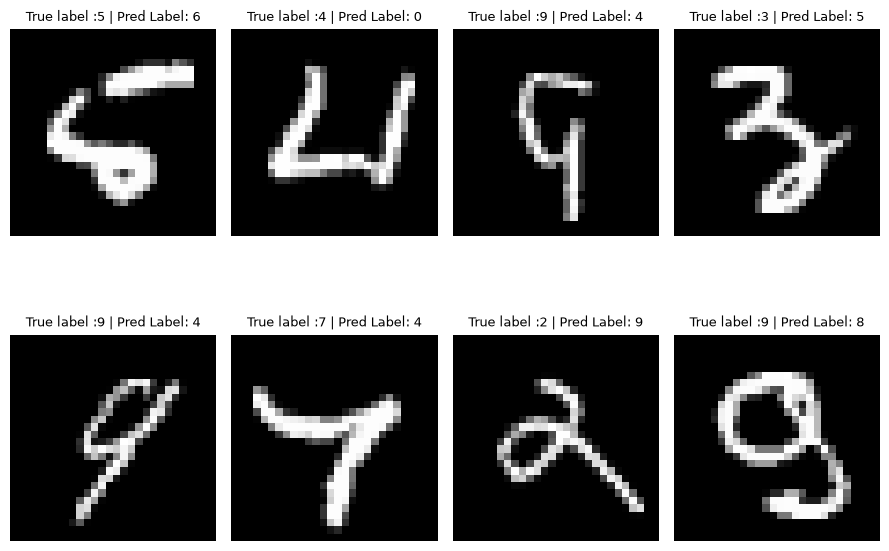

In [27]:
incorr_idx = np.where(y_pred != y_test)[0]# Gives 1-D Array of indices 
    
fig, axes = plt.subplots(2,4 ,figsize=(9, 7))
axes = axes.flatten() # flatten to easily iterate

for i in range(8):
    idx = incorr_idx[i]
    
    ax = axes[i]
    ax.imshow(X_test[idx], cmap='gray')
    ax.set_title(f'True label :{y_test[idx]} | Pred Label: {y_pred[idx]}', fontsize=9)
    ax.axis('off')
        
plt.tight_layout()
plt.show()  

In [28]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9225

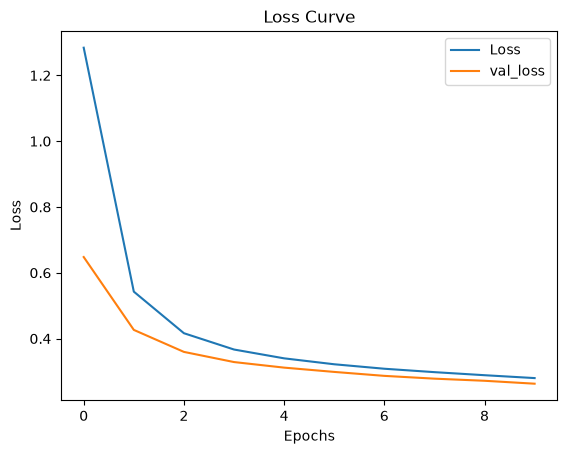

In [29]:
# =======================================
# MODULE 4: MODEL SCORE VISUALIZATION 
# =======================================

import matplotlib.pyplot as plt

# Training Loss vs  Validation Loss
plt.plot(hist.history['loss'], label='Loss')
plt.plot(hist.history['val_loss'], label ='val_loss')
plt.title("Loss Curve")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

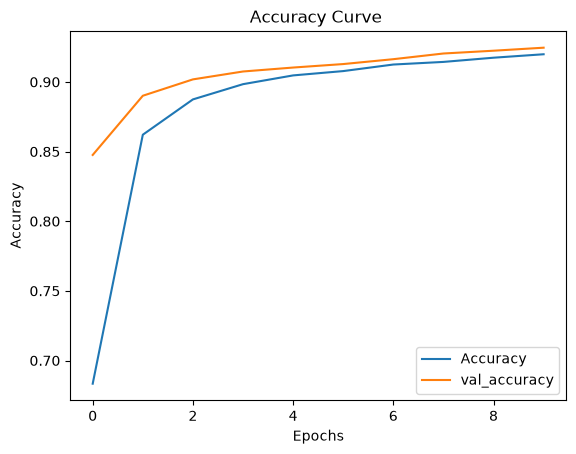

In [19]:
# Training accuracy vs Validation accuracy
plt.plot(hist.history['accuracy'], label ="Accuracy")
plt.plot(hist.history['val_accuracy'], label = "val_accuracy")
plt.title("Accuracy Curve ")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

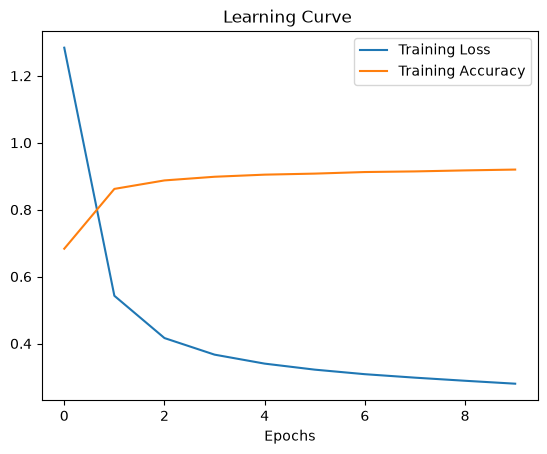

In [20]:
plt.plot(hist.history['loss'], label="Training Loss")
plt.plot(hist.history['accuracy'], label="Training Accuracy")
plt.title("Learning Curve ")
plt.xlabel('Epochs')
plt.legend()
plt.show()